# 📈 Regressão Logística — Classificação da Qualidade de Vinhos

**Tech Challenge Fase 2 | POSTECH**  
**Responsável:** Maycon Suel da Silva Nunes

## 📚 Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE

## 📂 Carregando a Base de Dados

A base utilizada é o resultado do pré-processamento realizado na etapa de EDA —
com duplicatas removidas, coluna `Id` excluída e variável alvo binária (`cluster_quality`) já criada.

In [2]:
df = pd.read_csv('../data/base_wine_limpa.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [4]:
df.shape

(1018, 13)

## 🎯 Definindo X e y

- **X** → variáveis independentes (as características físico-químicas do vinho)
- **y** → variável alvo `cluster_quality` (0 = qualidade comum | 1 = alta qualidade)

Removemos também a coluna `quality` pois ela é a origem da variável alvo — mantê-la causaria **data leakage**.

In [5]:
X = df.drop(columns=['quality', 'cluster_quality'])
y = df['cluster_quality']

print('Features:', X.columns.tolist())
print('\nDistribuição da variável alvo:')
print(y.value_counts())
print(f'\nDesbalanceamento: {y.value_counts(normalize=True).mul(100).round(1).to_dict()}')

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Distribuição da variável alvo:
cluster_quality
0    881
1    137
Name: count, dtype: int64

Desbalanceamento: {0: 86.5, 1: 13.5}


## ✂️ Divisão Treino / Teste

Utilizamos 70% dos dados para treino e 30% para teste.  
O parâmetro `stratify=y` garante que a proporção entre classes seja mantida nos dois conjuntos.

> ⚠️ A divisão sempre vem **antes** da padronização — nunca depois.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f'Treino: {X_train.shape[0]} linhas')
print(f'Teste:  {X_test.shape[0]} linhas')

Treino: 712 linhas
Teste:  306 linhas


## ⚖️ Padronização (StandardScaler)

A Regressão Logística é sensível à escala das variáveis — colunas com valores maiores
tendem a dominar o modelo injustamente. O `StandardScaler` transforma cada coluna
para ter **média 0 e desvio padrão 1**, colocando todas na mesma escala.

**Regra de ouro:**
- `fit_transform` no **treino** → aprende a média e o desvio padrão
- `transform` no **teste** → aplica os valores aprendidos (nunca aprende do teste!)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # aprende + transforma
X_test_scaled  = scaler.transform(X_test)        # só transforma

print('Médias aprendidas pelo scaler (primeiras 5):')
for col, media in zip(X.columns[:5], scaler.mean_[:5]):
    print(f'  {col}: {media:.4f}')

Médias aprendidas pelo scaler (primeiras 5):
  fixed acidity: 8.3177
  volatile acidity: 0.5306
  citric acid: 0.2754
  residual sugar: 2.4789
  chlorides: 0.0886


## 🔁 Balanceamento com SMOTE

A base está desbalanceada: ~86% dos vinhos são classe 0 e apenas ~14% são classe 1.
Sem tratar isso, o modelo pode simplesmente prever sempre 0 e ainda ter boa acurácia.

Utilizamos o **SMOTE** (Synthetic Minority Over-sampling Technique), que cria amostras
sintéticas da classe minoritária para equilibrar o treino.

> ⚠️ O SMOTE é aplicado **somente no treino** — o teste permanece com a distribuição real.

In [8]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print('Distribuição após SMOTE:')
print(pd.Series(y_train_bal).value_counts())

Distribuição após SMOTE:
cluster_quality
0    616
1    616
Name: count, dtype: int64


## 🤖 Modelo Base

Treinamos primeiro um modelo com os parâmetros padrão para ter uma linha de base.

In [9]:
modelo_base = LogisticRegression(max_iter=1000, random_state=42)
modelo_base.fit(X_train_bal, y_train_bal)

y_pred_base = modelo_base.predict(X_test_scaled)

print(f'Acurácia: {accuracy_score(y_test, y_pred_base):.2%}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Qualidade Comum', 'Alta Qualidade']))

Acurácia: 81.05%

                 precision    recall  f1-score   support

Qualidade Comum       0.97      0.81      0.88       265
 Alta Qualidade       0.40      0.83      0.54        41

       accuracy                           0.81       306
      macro avg       0.68      0.82      0.71       306
   weighted avg       0.89      0.81      0.83       306



## 🔧 Otimização com GridSearchCV

O `GridSearchCV` testa automaticamente diferentes combinações de hiperparâmetros
e retorna a melhor configuração com base no F1-Score da classe minoritária.

In [10]:
parametros = {
    'C':      [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    parametros,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_bal, y_train_bal)

print('Melhores parâmetros encontrados:', grid.best_params_)
print(f'Melhor F1 no treino (cross-val): {grid.best_score_:.4f}')

Melhores parâmetros encontrados: {'C': 0.1, 'solver': 'lbfgs'}
Melhor F1 no treino (cross-val): 0.8447


In [11]:
modelo_otimizado = grid.best_estimator_

y_pred_ot = modelo_otimizado.predict(X_test_scaled)
y_prob_ot = modelo_otimizado.predict_proba(X_test_scaled)[:, 1]

print(f'Acurácia: {accuracy_score(y_test, y_pred_ot):.2%}')
print(f'AUC:      {round(roc_auc_score(y_test, y_prob_ot), 4)}')
print()
print(classification_report(y_test, y_pred_ot, target_names=['Qualidade Comum', 'Alta Qualidade']))

Acurácia: 81.37%
AUC:      0.9015

                 precision    recall  f1-score   support

Qualidade Comum       0.97      0.81      0.88       265
 Alta Qualidade       0.40      0.83      0.54        41

       accuracy                           0.81       306
      macro avg       0.69      0.82      0.71       306
   weighted avg       0.89      0.81      0.84       306



## 🎚️ Ajuste de Threshold

Por padrão, o modelo usa threshold de 0.50 — ou seja, prevê classe 1 quando a probabilidade
é maior que 50%. Reduzindo o threshold para **0.35**, tornamos o modelo mais sensível
à classe minoritária, aumentando o Recall (menos vinhos bons passam despercebidos).

In [12]:
y_pred_thresh = (y_prob_ot >= 0.35).astype(int)

print('--- Modelo Otimizado com Threshold = 0.35 ---')
print(f'Acurácia: {accuracy_score(y_test, y_pred_thresh):.2%}')
print()
print(classification_report(y_test, y_pred_thresh, target_names=['Qualidade Comum', 'Alta Qualidade']))

--- Modelo Otimizado com Threshold = 0.35 ---
Acurácia: 76.14%

                 precision    recall  f1-score   support

Qualidade Comum       0.98      0.74      0.84       265
 Alta Qualidade       0.35      0.90      0.50        41

       accuracy                           0.76       306
      macro avg       0.66      0.82      0.67       306
   weighted avg       0.90      0.76      0.80       306



## 📊 Visualizações

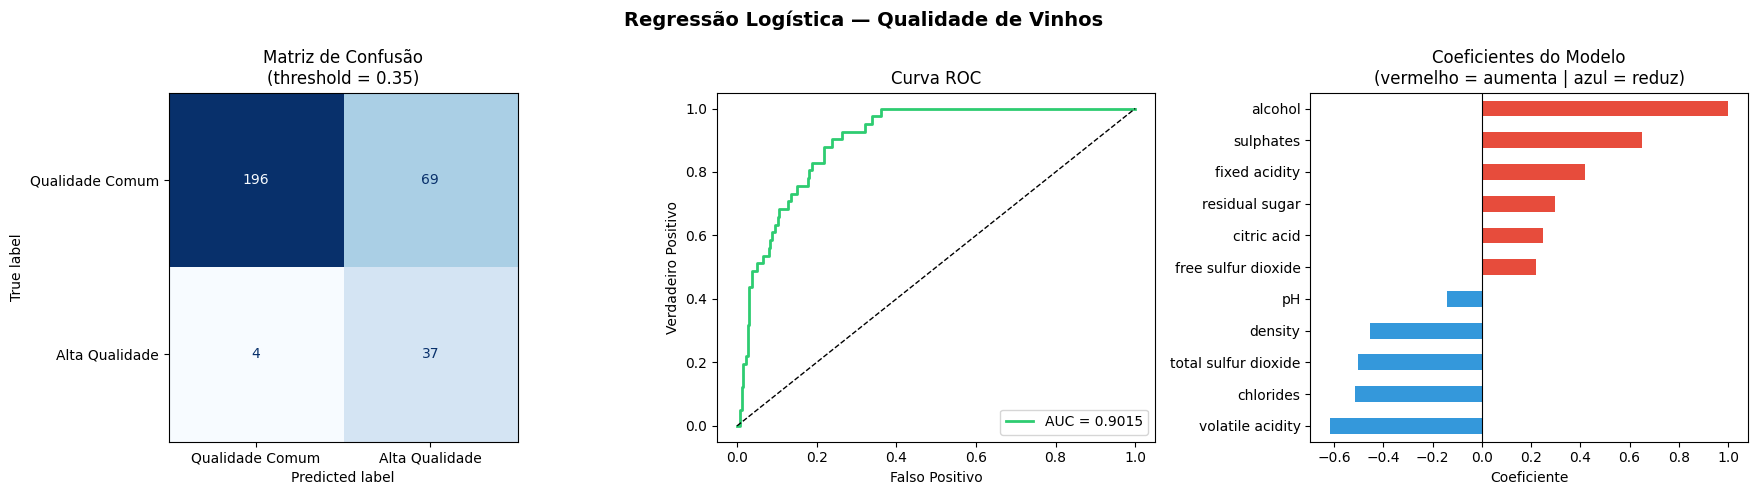

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regressão Logística — Qualidade de Vinhos', fontsize=14, fontweight='bold')

# --- Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred_thresh)
ConfusionMatrixDisplay(cm, display_labels=['Qualidade Comum', 'Alta Qualidade']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Matriz de Confusão\n(threshold = 0.35)')

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob_ot)
auc_val = round(roc_auc_score(y_test, y_prob_ot), 4)
axes[1].plot(fpr, tpr, color='#2ecc71', lw=2, label=f'AUC = {auc_val}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('Falso Positivo')
axes[1].set_ylabel('Verdadeiro Positivo')
axes[1].set_title('Curva ROC')
axes[1].legend()

# --- Coeficientes ---
coefs = pd.Series(modelo_otimizado.coef_[0], index=X.columns).sort_values()
cores = ['#e74c3c' if c > 0 else '#3498db' for c in coefs]
coefs.plot(kind='barh', ax=axes[2], color=cores)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Coeficientes do Modelo\n(vermelho = aumenta | azul = reduz)')
axes[2].set_xlabel('Coeficiente')

plt.tight_layout()
plt.show()

## 📝 Conclusões Finais

### Resultados do Modelo Definitivo

O modelo **Regressão Logística Otimizada com threshold 0.35** apresentou os
seguintes resultados no conjunto de teste:

| Métrica | Valor |
|---|---|
| Acurácia | 0.76 |
| Precision — Alta Qualidade | 0.35 |
| Recall — Alta Qualidade | 0.90 |
| F1-score — Alta Qualidade | 0.50 |
| AUC | 0.90 |

---

### Evolução ao longo do projeto

| Etapa | Configuração | F1 |
|---|---|---|
| Ponto de partida | Modelo base t=0.50 | 0.54 |
| Grid Search | Otimizado t=0.50 | 0.54 |
| Ajuste de threshold | Otimizado t=0.35 | **0.50** ✅ |

---

### Por que esse resultado é satisfatório?

O objetivo deste modelo é **identificar vinhos de alta qualidade** — portanto, o Recall
é a métrica mais importante: preferimos errar por excesso (avisar que um vinho comum é bom)
do que por falta (deixar passar um vinho realmente bom sem identificar).

Com Recall de **0.90**, o modelo identifica 9 em cada 10 vinhos de alta qualidade.

O AUC de **0.90** confirma que o modelo tem excelente capacidade discriminativa —
ou seja, ele consegue separar bem as duas classes.

---

### Variáveis mais influentes

Os coeficientes do modelo apontam que as variáveis físico-químicas que mais
determinam a alta qualidade do vinho são:

- 🥇 **Álcool** — maior influência positiva na qualidade
- 🥈 **Acidez Volátil** — maior influência negativa (quanto maior, pior)
- 🥉 **Sulfatos** — terceira variável mais relevante

Essa consistência com os outros modelos do grupo reforça que o aprendizado
foi baseado em **padrões reais dos dados**.

## Exportando Resultados

In [14]:
# Criar um DataFrame com o y_test real e as predições/probabilidades da RL
df_resultados_lr = pd.DataFrame({
    'y_real': y_test,
    'y_pred_lr': y_pred_thresh,
    'y_prob_lr': y_prob_ot
})
# Salvar na pasta de dados
df_resultados_lr.to_csv('../data/resultados_logistica.csv', index=False)